[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DVPombo/SOLETE/blob/main/examples/04_wind_forecasting.ipynb)

# 04 — Simple wind power forecasting

Mirrors `03_pv_forecasting.ipynb`'s structure for `P_Gaia[kW]` (the Gaia wind turbine's
active power output): a persistence baseline plus one simple ML model, on a held-out
split. Read the data note below before the results — it matters more than usual here.

**This notebook uses a different sample file, `SOLETE_sample_wind.h5`, not
`SOLETE_sample.h5`.** Here's why.

In [ ]:
# --- Colab / local setup -------------------------------------------------
# This cell makes the notebook runnable both from a local clone (the usual
# case) and from the "Open in Colab" badge above, where nothing but this
# .ipynb file exists yet in the Colab VM.
#
# 1. If `Functions.py` isn't found one directory up, we're not inside a local
#    clone of the repo (e.g. Colab) -- shallow-clone it once and move into
#    examples/, so the rest of this notebook (written assuming it runs from
#    examples/) works unmodified.
# 2. Either way, check whether the sample file this notebook needs is already
#    present before fetching it -- so re-running locally never re-downloads it.
import os
import subprocess
import urllib.request

ORG = "DVPombo"
REPO = "SOLETE"
BRANCH = "main"
SAMPLE_FILE = "SOLETE_sample_wind.h5"
REPO_URL = "https://github.com/" + ORG + "/" + REPO + ".git"

if not os.path.exists("../Functions.py"):
    if not os.path.isdir(REPO):
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL],
            check=True,
        )
    os.chdir(REPO + "/examples")
    print("Cloned " + ORG + "/" + REPO + "@" + BRANCH + " and switched into examples/.")

# Check-before-fetch: the sample file may already be sitting in examples/
# (its real location in this repo) or one level up (where the loader calls
# below expect it) -- only hit the network if it's in neither place.
sample_here = os.path.exists(SAMPLE_FILE)
sample_up = os.path.exists("../" + SAMPLE_FILE)

if sample_here or sample_up:
    print(SAMPLE_FILE + " already present locally, skipping download.")
else:
    url = "https://raw.githubusercontent.com/" + ORG + "/" + REPO + "/" + BRANCH + "/examples/" + SAMPLE_FILE
    dest = "../" + SAMPLE_FILE
    print(SAMPLE_FILE + " not found locally, fetching from GitHub...")
    urllib.request.urlretrieve(url, dest)
    print("Done.")


## Data note: `P_Gaia[kW]` is almost entirely zero in this dataset

While building this notebook, `P_Gaia[kW]` turned out to be exactly `0.0` for the
*entire* main Phase 3 sample window (Dec 2018 – Feb 2019) — and in fact for almost the
whole 15-month source file. Checking the full `SOLETE_Pombo_60min.h5`: only 48 of
10,969 rows (0.44%) have `P_Gaia[kW] > 0`, and they fall on exactly **two isolated
calendar days** (2018-08-31 and 2019-05-25), with every other hour reading exactly
zero — including thousands of hours where wind speed is well above the turbine's
3.5 m/s cut-in speed. This is a real, previously-undocumented characteristic of the
delivered data (see `SAMPLE_DATA.md` for the full writeup); per the maintainer, it's
most likely the turbine was out of service for most of the 15-month record — Gaia has a
documented history of mechanical problems — though that hasn't been independently
verified, and it isn't being added to `KNOWN_ISSUES.md`/`DATA_DICTIONARY.md` at this
time.

A persistence baseline on an all-zero target "forecasts" it perfectly (0.000 MAE/RMSE),
which would make this notebook look broken rather than demonstrate anything real. So
this notebook uses a **second, dedicated sample**, `SOLETE_sample_wind.h5` — 60 days
centered on the 2019-05-25 active day — instead of the main Phase 3 sample. Even so,
`P_Gaia[kW]` is non-zero on only 24 of this sample's 1,440 rows: the takeaway here is as
much about the dataset's limitations as about the forecasting methods.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from Functions import import_SOLETE_sample, import_PV_WT_data

pd.set_option('display.max_columns', None)
%matplotlib inline

Control_Var = {'OriginalFeatures': [], 'PossibleFeatures': []}
PVinfo, WTinfo = import_PV_WT_data()
df = import_SOLETE_sample('../SOLETE_sample_wind.h5', Control_Var, PVinfo, WTinfo)

print(f"P_Gaia[kW] > 0: {(df['P_Gaia[kW]'] > 0).sum()} of {len(df)} rows")

I0000 00:00:1789229018.552857     123 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789229018.596340     123 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789229019.963459     123 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


SOLETE sample was imported from: ../SOLETE_sample_wind.h5
    1440 rows, 2019-04-26 00:00:00 .. 2019-06-24 23:00:00

QC flags applied: {'Azimuth[deg]_qc': 1440, 'Elevation[deg]_qc': 1440, 'Pressure[mbar]_qc': 1440, 'HUMIDITY[%]_qc': 19, 'WIND_DIR[deg]_qc': 11} 

Expanding SOLETE with King's PV Performance Model
    Cleaning noise and curtailment from active power production
    QC flag (substitution): {'P_Solar[kW]_qc': 358}
    Smoothing zeros

Adding new Types with codes: []

SOLETE has been successfully expanded from: 11 to: 22 features.


P_Gaia[kW] > 0: 24 of 1440 rows


## Choosing a persistence baseline

Unlike solar power, wind power has no strong daily (diurnal) cycle — wind doesn't
"know" what time of day it is. The standard naive baseline for wind is therefore plain
**`t-1` persistence** ("next value = last value"), not the `t-24` same-hour-yesterday
baseline used for `P_Solar[kW]` in notebook 3.

In [2]:
target = 'P_Gaia[kW]'

data = df[[target, 'WIND_SPEED[m1s]', 'WIND_DIR[deg]', 'WIND_DIR[deg]_qc']].copy()
data['lag_1'] = data[target].shift(1)
data['wind_speed_lag_1'] = data['WIND_SPEED[m1s]'].shift(1)
data['persistence_pred'] = data['lag_1']
data = data.dropna()
print(data.shape)
data.head()

(1439, 7)


,P_Gaia[kW],WIND_SPEED[m1s],WIND_DIR[deg],WIND_DIR[deg]_qc,lag_1,wind_speed_lag_1,persistence_pred
2019-04-26 01:00:00,0.0,1.271778,131.592222,0,0.0,1.629861,0.0
2019-04-26 02:00:00,0.0,1.710028,124.674444,0,0.0,1.271778,0.0
2019-04-26 03:00:00,0.0,1.538972,130.279167,0,0.0,1.710028,0.0
2019-04-26 04:00:00,0.0,1.066056,129.148333,0,0.0,1.538972,0.0
2019-04-26 05:00:00,0.0,1.524750,122.755833,0,0.0,1.066056,0.0


## The `WIND_DIR[deg]`-as-feature question

Unlike Task 3's `P_Solar[kW]_qc` case (a flagged **target**, replaced by another model's
output — a real circularity risk), this is a flagged **feature**: `WIND_DIR[deg]` has a
small share of physically-implausible rows (`≥ 360°`, `WIND_DIR[deg]_qc == 3`) in this
sample, and we're about to feed it to the model as an input, not evaluate against it.

In [3]:
wd_flagged_share = (data['WIND_DIR[deg]_qc'] == 3).mean()
print(f"{wd_flagged_share:.1%} of rows have WIND_DIR[deg] flagged physically_implausible")

0.8% of rows have WIND_DIR[deg] flagged physically_implausible


**Decision for this notebook: keep these rows as-is, and just note the tradeoff.**
Excluding them would need either dropping the rows entirely (losing training/test data
we can't spare in an already-tiny active-wind sample) or imputing a replacement value
(introducing a different, silent assumption). A flagged feature value can still carry
partial signal — a wind direction wrapped past 360° is wrong as a *compass bearing* but
its raw magnitude may still correlate weakly with whatever caused the reading — whereas
a flagged **target** value is actively circular to evaluate against, which is why
notebook 3 excluded those rows outright and this one doesn't. A stricter notebook could
reasonably impute or drop these instead; this is a judgment call, not a settled rule, and
the right choice may differ for a real deployment versus this teaching demo.

## Train/test split and the simple model

In [4]:
feature_cols = ['lag_1', 'wind_speed_lag_1', 'WIND_DIR[deg]']
X = data[feature_cols]
y = data[target]

split = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
persistence_test = data['persistence_pred'].iloc[split:]

print(f"Train: {len(X_train)} rows, Test: {len(X_test)} rows "
      f"(P_Gaia[kW] > 0 in test set: {(y_test > 0).sum()} rows)")

model = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=0)
model.fit(X_train, y_train)
rf_pred = pd.Series(model.predict(X_test), index=X_test.index)

Train: 1151 rows, Test: 288 rows (P_Gaia[kW] > 0 in test set: 0 rows)


## Results

In [5]:
def score(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred), root_mean_squared_error(y_true, y_pred)

pers_mae, pers_rmse = score(y_test, persistence_test)
rf_mae, rf_rmse = score(y_test, rf_pred)

results = pd.DataFrame({
    'MAE [kW]': [pers_mae, rf_mae],
    'RMSE [kW]': [pers_rmse, rf_rmse],
}, index=['Persistence (t-1)', 'Random Forest'])
results

,MAE [kW],RMSE [kW]
Persistence (t-1),0.000000,0.00000
Random Forest,0.001291,0.02191


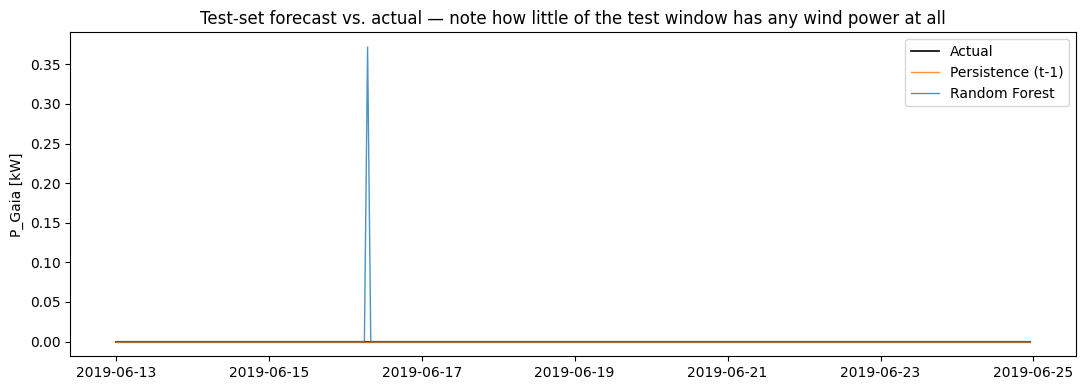

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y_test.index, y_test, label='Actual', color='black', linewidth=1.2)
ax.plot(y_test.index, persistence_test, label='Persistence (t-1)', color='tab:orange',
        linewidth=1, alpha=0.8)
ax.plot(y_test.index, rf_pred, label='Random Forest', color='tab:blue', linewidth=1, alpha=0.8)
ax.set_ylabel('P_Gaia [kW]')
ax.set_title('Test-set forecast vs. actual — note how little of the test window has any wind power at all')
ax.legend()
fig.tight_layout()
plt.show()

## Takeaway

In this run, the chronological 80/20 split puts the entire test set *after* the one
active wind day (2019-05-25 falls in training, not test) — so the test set is literally
all zeros. That's exactly why persistence scores a perfect 0.000 MAE/RMSE here: it isn't
that persistence is a good wind forecaster, it's that predicting zero for an all-zero
target is free. The Random Forest actually scores *worse* by this metric (0.001 MAE)
purely because it learned some non-zero structure from training and predicts small noise
around zero instead of exact zero. Neither result says anything real about forecasting
ability — it's the split interacting with how rare non-zero wind power is in this sample.
A meaningful wind-power forecasting demo on SOLETE would need either a period confirmed
to have the turbine actually operating throughout, or a different, more complete
wind-power source altogether — worth flagging for whoever picks up wind forecasting on
this dataset next.